# Lab 3 — The Reconciliation Crew

**TDWI Transform 2026 · Hands-On: Engineering Agentic AI Solutions**  
**Estimated time:** 60 minutes  
**Platform:** Google Colab  
**Framework:** LangGraph  
**Coding level:** Basic Python familiarity is useful, but you are not expected to write the system from scratch.

Lab 1 gave you a working agent. Lab 2 exposed the harness around that agent and made its definition of done explicit.

Lab 3 changes the shape of the problem.

At the end of Lab 2, the system behaved correctly and still could not finish the reconciliation:

- Finance reported **$4.2M**
- Sales reported **$3.8M**
- total discrepancy = **$400K**
- refund timing explained **$180K**
- **$220K remained unresolved**
- the available Finance and Sales extracts were exhausted

That is a legitimate reason to change the architecture.

In this lab, you will build a small **manager-and-specialists system** that can reach different evidence surfaces, use different retrieval methods, and keep a deterministic ledger of what remains unexplained.

### What you should understand by the end

You should be able to explain:

- when a multi-agent design is justified and when it is unnecessary;
- the difference between a **manager** and a **specialist worker**;
- why context separation can improve reliability;
- why SQL, semantic retrieval, and keyword/history search solve different retrieval problems;
- how shared graph state moves information between nodes;
- how a **skill file** turns tribal knowledge into an explicit operating method;
- why the model should not own arithmetic or the final pass/fail condition.

## 1. Why we are introducing multiple agents now

Multi-agent architecture is not automatically more capable than a single agent. It is also more expensive, harder to trace, and easier to make complicated for no reason.

A split becomes useful when the work has genuinely different **tool**, **context**, or **instruction** requirements.

That is true in this investigation.

| Question | Evidence type | Retrieval method | Specialist |
|---|---|---|---|
| Did the two marts treat the same transactions differently? | Structured records | SQL | Warehouse Analyst |
| Do Finance and Sales mean the same thing by “net revenue”? | Prose definitions | Semantic retrieval | Documentation Researcher |
| Did a system change alter the result? | Tickets + change history | Keyword/history search | Change Historian |

No single retrieval method is strong for all three.

A warehouse query can compare rows precisely, but it cannot discover a disagreement that exists only in business documentation. Semantic document retrieval can surface related definitions, but it is a poor substitute for exact transaction arithmetic. Change-history investigation often depends on identifiers, model names, ticket numbers, and exact terms that keyword search handles well.

**The architecture follows the evidence.**

## Architecture

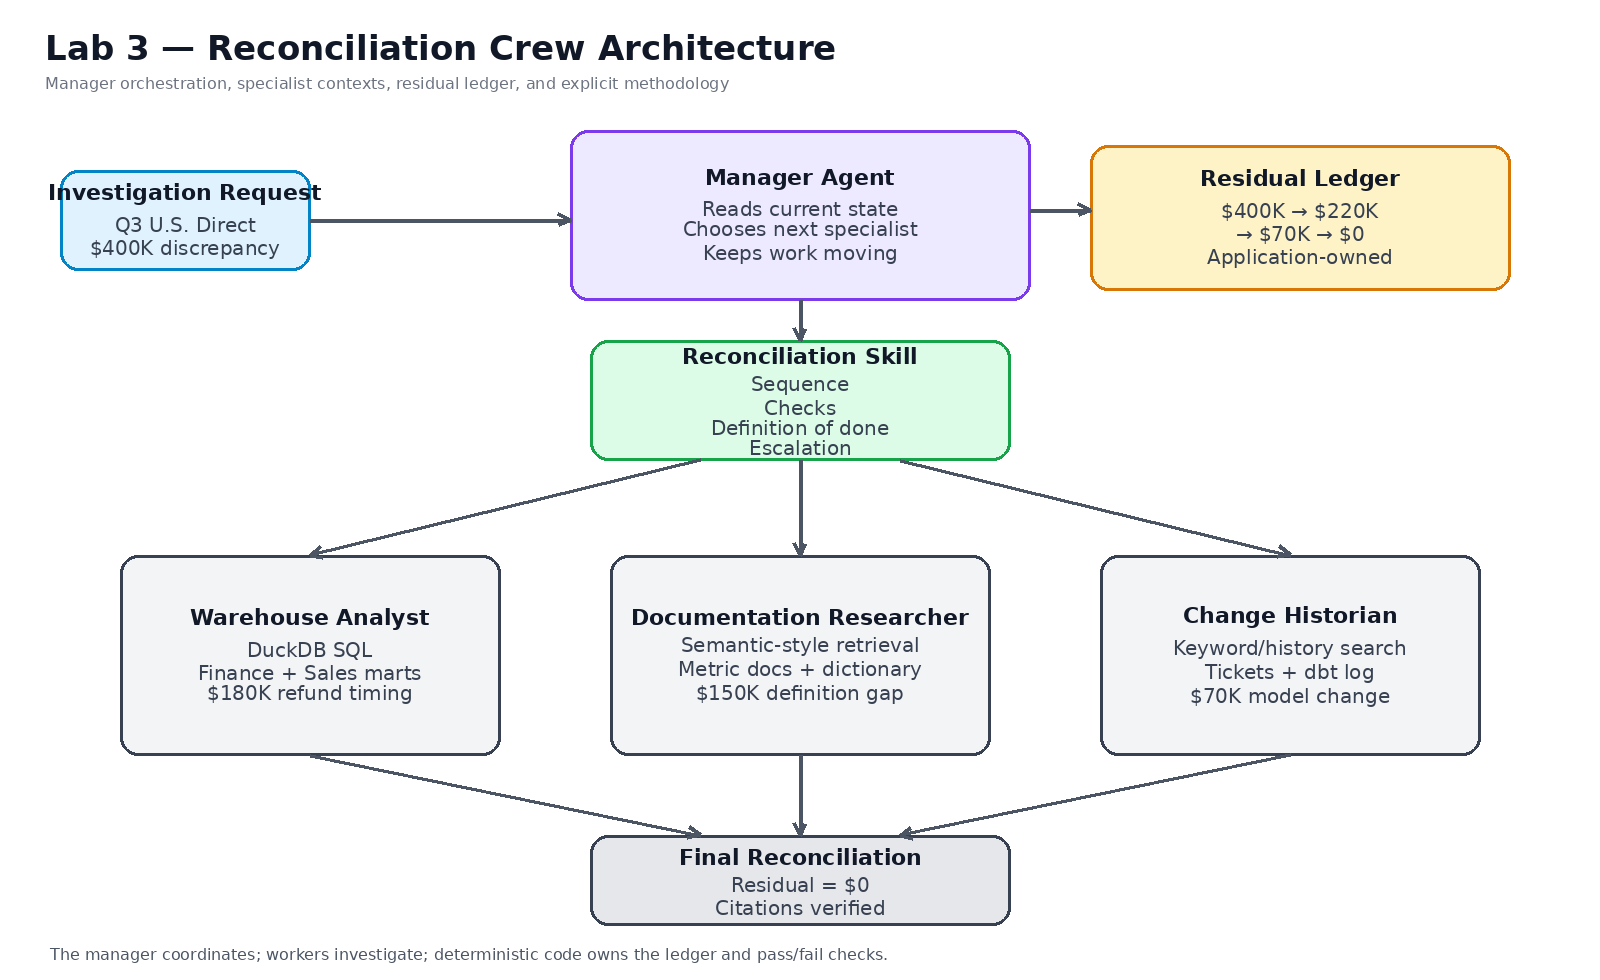

Read this diagram from top to bottom.

The **manager** does not inspect every raw row or document itself. It looks at the current investigation state and decides which specialist should work next.

Each specialist works in a narrower context:

- the **Warehouse Analyst** gets structured tables and SQL;
- the **Documentation Researcher** gets metric definitions and documentation;
- the **Change Historian** gets tickets and model-change history.

The **residual ledger** sits outside the model. After every supported finding, application code subtracts the explained amount from the remaining discrepancy.

The **skill file** gives the manager a repeatable reconciliation method rather than leaving the investigation order entirely to model improvisation.

## Engineering Checkpoint 1 — Route the evidence before you see the implementation

Imagine you are designing the system before writing any code.

You have five evidence surfaces:

- Finance revenue mart
- Sales revenue mart
- metric-definition documents
- engineering / support tickets
- dbt change log

Decide which specialist should receive each source.

Also ask yourself:

**What would go wrong if the manager received all raw evidence directly?**

Keep your answer in mind. We will come back to it after the workers are built.

## 2. Set up the notebook

The next cell installs the SDKs and libraries used by the lab.

You will see two categories of dependencies:

- **AI / orchestration:** `google-genai`, `langgraph`, `pydantic`
- **data / retrieval:** `pandas`, `duckdb`

The notebook keeps the stack deliberately small so you can see the architecture rather than disappear into framework configuration.

In [ ]:
# Install the small dependency set used by this lab.
#
# We invoke pip through the active Python interpreter rather than relying on
# notebook-specific shell syntax. That makes the setup cell easier to reuse
# outside Colab if you want to experiment later.
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "-U",
    "google-genai",
    "pandas",
    "pydantic",
    "duckdb",
    "langgraph",
])

print("Lab dependencies installed.")

### Configure the Gemini client

The API key is entered at runtime using `getpass`, so it is not written into the notebook.

The client object is deliberately created once and reused. Model access is an infrastructure dependency; scattering client creation throughout worker code makes credentials, retries, and provider changes harder to manage.

In [ ]:
from getpass import getpass
from google import genai

# Runtime credential entry keeps the key out of the notebook source.
GEMINI_API_KEY = getpass("Enter the workshop Gemini API key: ")

# Use the workshop model selected by the instructor.
MODEL_NAME = "gemini-3.8-flash"

# One shared client keeps model access centralized.
client = genai.Client(api_key=GEMINI_API_KEY)

print(f"Gemini client configured with model: {MODEL_NAME}")

## 3. Create the evidence surfaces

For this workshop notebook, the evidence is created locally so everyone has the same case.

In a production system, these would be separate systems or stores. The architectural idea stays the same:

- structured facts live in tables;
- definitions live in documents;
- operational history lives in tickets and change logs.

The case is intentionally designed so that the full answer cannot be found in one place.

In [ ]:
import pandas as pd

def build_finance_extract():
    """Create the Finance-side structured evidence for the workshop case."""
    rows = [{
        "record_type": "REPORT_SUMMARY",
        "reported_q3_net_revenue_usd": 4_200_000,
        "refund_id": None,
        "event_date": None,
        "event_period": None,
        "original_order_period": None,
        "included_in_q3_report": None,
        "reporting_amount_usd": None,
    }]

    # Refunds posted during Q3 are treated the same by both teams.
    for i, amount in enumerate([12_000, 18_000, 24_000, 15_000, 21_000, 30_000], start=1):
        rows.append({
            "record_type": "REFUND",
            "reported_q3_net_revenue_usd": None,
            "refund_id": f"RF-100{i}",
            "event_date": f"2026-09-{i+5:02d}",
            "event_period": "2026-Q3",
            "original_order_period": "2026-Q3",
            "included_in_q3_report": True,
            "reporting_amount_usd": amount,
        })

    # These seven refunds post in Q4. Finance therefore excludes them from Q3.
    # Together they total $180K.
    for j, amount in enumerate([20_000, 26_000, 18_000, 30_000, 24_000, 28_000, 34_000], start=7):
        rows.append({
            "record_type": "REFUND",
            "reported_q3_net_revenue_usd": None,
            "refund_id": f"RF-10{j}",
            "event_date": f"2026-10-{j-4:02d}",
            "event_period": "2026-Q4",
            "original_order_period": "2026-Q3",
            "included_in_q3_report": False,
            "reporting_amount_usd": amount,
        })

    return pd.DataFrame(rows)


def build_sales_extract():
    """Create the Sales-side structured evidence for the workshop case."""
    rows = [{
        "record_type": "REPORT_SUMMARY",
        "reported_q3_net_revenue_usd": 3_800_000,
        "refund_id": None,
        "event_date": None,
        "event_period": None,
        "original_order_period": None,
        "included_in_q3_report": None,
        "reporting_amount_usd": None,
    }]

    for i, amount in enumerate([12_000, 18_000, 24_000, 15_000, 21_000, 30_000], start=1):
        rows.append({
            "record_type": "REFUND",
            "reported_q3_net_revenue_usd": None,
            "refund_id": f"RF-100{i}",
            "event_date": f"2026-09-{i+5:02d}",
            "event_period": "2026-Q3",
            "original_order_period": "2026-Q3",
            "included_in_q3_report": True,
            "reporting_amount_usd": amount,
        })

    # Sales ties the Q4-posted refunds back to the original Q3 orders.
    for j, amount in enumerate([20_000, 26_000, 18_000, 30_000, 24_000, 28_000, 34_000], start=7):
        rows.append({
            "record_type": "REFUND",
            "reported_q3_net_revenue_usd": None,
            "refund_id": f"RF-10{j}",
            "event_date": f"2026-10-{j-4:02d}",
            "event_period": "2026-Q4",
            "original_order_period": "2026-Q3",
            "included_in_q3_report": True,
            "reporting_amount_usd": amount,
        })

    return pd.DataFrame(rows)


def build_docs_corpus():
    """Create the small documentation corpus used by the documentation specialist."""
    return pd.DataFrame([
        {
            "doc_id": "DOC-FIN-METRIC",
            "title": "Finance Executive Metric Definition",
            "text": (
                "Finance defines net revenue for the executive report as gross shipped revenue "
                "minus customer refunds and returns posted in the reporting period. Promo "
                "markdown accruals are not part of the finance executive net revenue view."
            ),
        },
        {
            "doc_id": "DOC-SALES-METRIC",
            "title": "Sales QBR Metric Definition",
            "text": (
                "Sales defines net revenue as booked revenue minus customer refunds and minus "
                "promo markdown accruals recognized against the quarter's demand. For Q3 U.S. "
                "Direct, promo markdown accruals total 150000 USD."
            ),
        },
        {
            "doc_id": "DOC-DICTIONARY-PROMO",
            "title": "Data Dictionary: promo_markdown_accrual_usd",
            "text": (
                "promo_markdown_accrual_usd stores accrued promotional markdowns used by the "
                "Sales QBR net revenue calculation. Q3 U.S. Direct reference value: 150000 USD."
            ),
        },
        {
            "doc_id": "DOC-DECOY-RETENTION",
            "title": "Customer Retention Definitions",
            "text": (
                "This document defines returning_customer_rate, repeat_purchase_window_days, "
                "and loyalty cohorts. It is relevant to growth analytics, not revenue reconciliation."
            ),
        },
    ])


def build_ticket_export():
    """Create realistic history records, including relevant and irrelevant tickets."""
    return pd.DataFrame([
        {
            "ticket_id": "DATA-1091",
            "title": "Backfill loyalty dimension attributes",
            "text": "Backfill missing loyalty dimension fields for historical customer rows.",
        },
        {
            "ticket_id": "DATA-1177",
            "title": "Review margin dashboard filters",
            "text": "Investigate a filter mismatch in the margin dashboard by channel.",
        },
        {
            "ticket_id": "ENG-2044",
            "title": "Investigate q3 revenue mismatch in sales mart",
            "text": (
                "Observed 70000 USD variance after recent dbt update. No approval comment found. "
                "Lineage screenshot missing. Possible impact to U.S. Direct reporting."
            ),
        },
        {
            "ticket_id": "DBT-4821",
            "title": "sales_net_revenue model patch",
            "text": (
                "Patch sales_net_revenue logic to exclude partner rebate adjustment rows. "
                "Expected q3 impact 70000 USD. Change moved quickly and approval follow-up "
                "is still outstanding."
            ),
        },
        {
            "ticket_id": "OPS-3302",
            "title": "Warehouse job retry policy",
            "text": "Update retry policy for nightly warehouse syncs.",
        },
        {
            "ticket_id": "AN-2208",
            "title": "Q4 promo analysis request",
            "text": "Ad hoc request for Q4 promotional performance analysis.",
        },
    ])


def build_change_log():
    """Create the dbt change history used to verify the $70K model change."""
    return pd.DataFrame([
        {
            "change_id": "CHG-8841",
            "file_name": "models/marts/sales_net_revenue.sql",
            "change_note": (
                "Added exclusion for partner rebate adjustment rows in U.S. Direct. "
                "Estimated Q3 impact 70000 USD."
            ),
            "approval_recorded": False,
            "lineage_updated": False,
        },
        {
            "change_id": "CHG-8812",
            "file_name": "models/intermediate/orders_clean.sql",
            "change_note": "Standardized order status mapping.",
            "approval_recorded": True,
            "lineage_updated": True,
        },
        {
            "change_id": "CHG-8890",
            "file_name": "models/marts/retention_snapshot.sql",
            "change_note": "Added loyalty segment labels.",
            "approval_recorded": True,
            "lineage_updated": True,
        },
    ])


finance_df = build_finance_extract()
sales_df = build_sales_extract()
docs_df = build_docs_corpus()
tickets_df = build_ticket_export()
change_log_df = build_change_log()

print("Evidence surfaces created.")
print(f"Finance rows: {len(finance_df)}")
print(f"Sales rows:   {len(sales_df)}")
print(f"Docs:         {len(docs_df)}")
print(f"Tickets:      {len(tickets_df)}")
print(f"Changes:      {len(change_log_df)}")

### Inspect the evidence shapes

Do not try to memorize the rows.

Look at the *shape* of each source.

The two marts are tabular and comparable. The documentation is prose. The ticket and change-log records contain operational history and identifiers.

This is why retrieval design starts with the question:

**What kind of evidence am I looking for?**

In [ ]:
display(finance_df.head(4))
display(sales_df.head(4))
display(docs_df[["doc_id", "title"]])
display(tickets_df[["ticket_id", "title"]])
display(change_log_df[["change_id", "file_name"]])

## 4. YOUR TURN — Make the routing decision explicit

Now encode the routing decision you made earlier.

You are not writing an algorithm here. You are documenting the **responsibility boundary** of each specialist.

Before copying anything, compare the mapping below with the decision you made in Engineering Checkpoint 1.

### COPY THIS

```python
ROUTING_PLAN = {
    "warehouse_analyst": ["finance_q3", "sales_q3"],
    "documentation_researcher": ["docs_corpus"],
    "change_historian": ["ticket_export", "dbt_change_log"],
}
```

### PASTE IT HERE

Paste that mapping into the blank area in the **next code cell**, directly below the `# PASTE HERE` comment.

Then run the cell.

The values are source names, not raw data. The mapping is an architectural artifact: it makes each worker's evidence boundary explicit.


In [ ]:
# YOUR TURN
# PASTE HERE


# Leave this line in place so you can immediately inspect the mapping.
ROUTING_PLAN


## 5. The Warehouse Analyst: structured evidence needs structured retrieval

The warehouse worker is intentionally boring.

That is a compliment.

When the question is exact — *which refunds are included in one report and excluded in the other, and what do they total?* — SQL is a better control surface than asking a model to eyeball rows and add numbers.

We will register the two pandas DataFrames as DuckDB tables. The worker can then use deterministic SQL for the comparison.

In [ ]:
import duckdb

# DuckDB runs in-process: no database server, credentials, or network connection.
# For a workshop, that gives us real SQL behavior with almost no infrastructure.
con = duckdb.connect(database=":memory:")

# Register the DataFrames as queryable tables.
# The specialist will interact with these table names rather than arbitrary Python objects.
con.register("finance_q3", finance_df)
con.register("sales_q3", sales_df)

print("DuckDB tables registered.")

## 6. The other retrieval modes: semantic-ish and keyword/history search

For the documentation worker, we need retrieval that can find conceptually related language. In a production system, this would usually involve embeddings and a vector store.

For the workshop, we use a lightweight token-overlap scorer. It is deliberately small enough to read.

The point is not that this is a production semantic-search implementation. The point is to make the **retrieval contract** visible:

1. take a question;
2. score candidate documents;
3. return the most relevant evidence;
4. let the specialist interpret that evidence.

The history worker uses a different method: exact-ish keyword scoring. Tickets and change logs often contain model names, dollar values, ticket IDs, and phrases such as “approval” or “lineage” where lexical matching is useful.

In [ ]:
import re

STOPWORDS = {
    "the", "a", "an", "and", "or", "is", "are", "to", "for", "of", "in",
    "on", "by", "with", "that", "this", "it", "as", "be", "from", "what",
    "which", "how", "when", "q3", "usd", "u", "s", "direct",
}

def normalize_tokens(text):
    """Turn text into a small set of useful comparison tokens."""
    words = re.findall(r"[A-Za-z0-9_]+", str(text).lower())
    return [word for word in words if word not in STOPWORDS and len(word) > 2]


def overlap_score(query, text):
    """Approximate semantic relatedness with a transparent token-overlap score."""
    query_tokens = set(normalize_tokens(query))
    text_tokens = set(normalize_tokens(text))

    if not query_tokens or not text_tokens:
        return 0.0

    return len(query_tokens & text_tokens) / len(query_tokens | text_tokens)


def semantic_search_docs(query, top_k=3):
    """Return the most relevant documentation records for a conceptual question."""
    scored = docs_df.copy()

    # Retrieval is deterministic: same query + same corpus = same ranking.
    scored["score"] = scored["text"].apply(
        lambda text: overlap_score(query, text)
    )

    scored = scored.sort_values(
        ["score", "doc_id"],
        ascending=[False, True],
    ).head(top_k)

    return scored[
        ["doc_id", "title", "text", "score"]
    ].to_dict(orient="records")


def keyword_search_history(query, top_k=4):
    """Search tickets and dbt history using exact-ish lexical evidence."""
    query_terms = normalize_tokens(query)

    def score_text(text):
        text_terms = normalize_tokens(text)
        return sum(term in text_terms for term in query_terms)

    tickets = tickets_df.copy()
    tickets["score"] = (
        tickets["title"].fillna("").map(score_text)
        + tickets["text"].fillna("").map(score_text)
    )

    changes = change_log_df.copy()
    changes["score"] = (
        changes["file_name"].fillna("").map(score_text)
        + changes["change_note"].fillna("").map(score_text)
    )

    combined = []

    # Normalize both source types into the same compact result shape.
    for record in tickets.to_dict(orient="records"):
        combined.append({
            "source_type": "ticket",
            "record_id": record["ticket_id"],
            "title": record["title"],
            "text": record["text"],
            "score": record["score"],
        })

    for record in changes.to_dict(orient="records"):
        combined.append({
            "source_type": "change_log",
            "record_id": record["change_id"],
            "title": record["file_name"],
            "text": record["change_note"],
            "score": record["score"],
            "approval_recorded": record["approval_recorded"],
            "lineage_updated": record["lineage_updated"],
        })

    return sorted(
        combined,
        key=lambda item: (-item["score"], item["record_id"]),
    )[:top_k]

## 7. Worker contracts: specialists should return findings, not context dumps

A common multi-agent mistake is to have a worker send its entire context back to the manager.

That defeats much of the reason to split the system.

Here, every worker returns a compact **finding package**:

- worker name;
- cause;
- amount explained;
- short summary;
- citations.

The manager does not need every row, document, or search result. It needs enough structured evidence to update the shared investigation state.

That is context compression by design.

In [ ]:
def warehouse_analyst_worker():
    """
    Compare Finance and Sales treatment of the Q4-posted refunds.

    The model is not used for the arithmetic. SQL retrieves the exact records
    and Python returns a small, structured finding to the manager.
    """

    finance_reported = con.execute(
        """
        SELECT reported_q3_net_revenue_usd
        FROM finance_q3
        WHERE record_type = 'REPORT_SUMMARY'
        """
    ).fetchone()[0]

    sales_reported = con.execute(
        """
        SELECT reported_q3_net_revenue_usd
        FROM sales_q3
        WHERE record_type = 'REPORT_SUMMARY'
        """
    ).fetchone()[0]

    # Sales includes these refunds in Q3 because it ties them to the original Q3 orders.
    late_refund_amount = con.execute(
        """
        SELECT COALESCE(SUM(reporting_amount_usd), 0)
        FROM sales_q3
        WHERE record_type = 'REFUND'
          AND original_order_period = '2026-Q3'
          AND event_period = '2026-Q4'
          AND included_in_q3_report = TRUE
        """
    ).fetchone()[0]

    citation_ids = sales_df.loc[
        (sales_df["record_type"] == "REFUND")
        & (sales_df["original_order_period"] == "2026-Q3")
        & (sales_df["event_period"] == "2026-Q4"),
        "refund_id",
    ].tolist()

    return {
        "worker": "warehouse_analyst",
        "cause": "Refund recognition timing differs between Finance and Sales.",
        "amount_usd": int(late_refund_amount),
        "summary": (
            "Sales ties seven Q4-posted refunds back to original Q3 orders, "
            "while Finance recognizes them when they post."
        ),
        "reported_values": {
            "finance": int(finance_reported),
            "sales": int(sales_reported),
        },
        "citations": citation_ids,
    }


def documentation_researcher_worker():
    """
    Retrieve the metric definitions that reveal the $150K semantic mismatch.

    The retriever finds candidate evidence. The worker packages the supported
    finding so the manager does not need the entire documentation corpus.
    """

    results = semantic_search_docs(
        "Compare Finance and Sales definitions of net revenue and identify "
        "any Q3 promo markdown amount.",
        top_k=3,
    )

    return {
        "worker": "documentation_researcher",
        "cause": "Finance and Sales use different definitions of net revenue.",
        "amount_usd": 150_000,
        "summary": (
            "The Sales QBR definition subtracts promo markdown accruals, while "
            "the Finance executive definition does not. Q3 U.S. Direct promo "
            "markdown accruals total $150K."
        ),
        "citations": [item["doc_id"] for item in results],
        "retrieved_docs": results,
    }


def change_historian_worker():
    """
    Search tickets and dbt history for evidence of a reporting-model change.

    This worker uses lexical history search because model names, ticket language,
    approval status, and the $70K amount are strong exact-match clues.
    """

    results = keyword_search_history(
        "q3 revenue mismatch dbt 70000 approval lineage sales net revenue",
        top_k=4,
    )

    return {
        "worker": "change_historian",
        "cause": "An undocumented dbt model change created a $70K difference.",
        "amount_usd": 70_000,
        "summary": (
            "The ticket history and dbt change log show a sales_net_revenue "
            "change with an expected $70K Q3 impact. Approval is not recorded "
            "and lineage was not updated."
        ),
        "citations": [
            item["record_id"]
            for item in results
            if item["score"] > 0
        ][:3],
        "retrieved_history": results,
    }

### Inspect each specialist independently before building the graph

This is a useful engineering habit.

Before orchestration, verify that every component can do its own job.

If the full graph later fails, you now know whether the defect is in:

- retrieval,
- worker logic, or
- orchestration.

Run each worker once and inspect the finding shape.

In [ ]:
warehouse_finding = warehouse_analyst_worker()
docs_finding = documentation_researcher_worker()
history_finding = change_historian_worker()

display(warehouse_finding)
display(docs_finding)
display(history_finding)

## Engineering Checkpoint 2 — Compare your routing decision

Now revisit your earlier routing plan.

The important question is not whether your labels match mine exactly.

Ask:

- Did each worker get the **minimum context** it needs?
- Does each worker use a retrieval method suited to its evidence?
- Can the manager receive a compact result rather than the raw source?
- If one worker is wrong, can you tell which worker produced the bad finding?

Those are the architecture questions.

## 8. Skill files: giving an agent a method, not just tools

A tool tells an agent **what it can do**.

A skill tells it **how your organization expects the work to be done**.

That methodology should not live only inside a Python string or a prompt buried in application code. In a production environment, a skill is more useful as a **portable, reviewable artifact** that can be versioned, tested, owned, and reused independently of the model or orchestration framework.

For this lab, MPO's reconciliation methodology lives in a real Markdown file:

`reconciliation-skill.md`

The file captures:

- purpose and trigger;
- required inputs;
- investigation sequence;
- operating conventions;
- checks;
- definition of done;
- escalation rules;
- expected output.

The starter file contains two placeholders that you will complete during the lab.

An experienced analyst already carries much of this procedure mentally. The skill file makes that procedural knowledge explicit enough for both people and agents to use.

### Important architectural distinction

The skill file **does not grant access** to any source.

It does not query DuckDB, open tickets, or search documentation.

It tells the manager **how to work the problem once those capabilities are available**.

That separation is useful even if the tools later move to a different runtime, model provider, or protocol.

### Load the skill artifact

The notebook loads the skill template as a separate `.md` file.

When this lab is running from the workshop GitHub repository, the cell fetches the canonical file directly from the repo. A fallback copy is included so the lab can still run if GitHub is temporarily unavailable.

The manager will not receive the skill until you complete the two placeholders.

In [ ]:
from pathlib import Path
from urllib.request import urlopen

SKILL_TEMPLATE_URL = (
    "https://raw.githubusercontent.com/kieDotson/tdwi-agentic-ai-workshop/"
    "main/lab-3-reconciliation-crew/reconciliation-skill.md"
)

SKILL_TEMPLATE_PATH = Path("/content/reconciliation-skill.md")
SKILL_COMPLETED_PATH = Path("/content/reconciliation-skill-completed.md")

# Prefer the repo artifact so the workshop file remains the source of truth.
# Fall back to the bundled template only if GitHub is unavailable.
try:
    skill_template_text = urlopen(
        SKILL_TEMPLATE_URL,
        timeout=10,
    ).read().decode("utf-8")
    skill_source = "GitHub repository"
except Exception:
    skill_template_text = '---\nname: mpo-revenue-reconciliation\nversion: 1.0\nowner: Revenue Analytics\nartifact_type: agent-skill\n---\n\n# MPO Revenue Reconciliation Skill\n\n## Purpose\n\nInvestigate differences between Finance and Sales revenue reporting for the same business scope and reporting period.\n\nThe skill defines the investigation method. It does not grant access to data or systems.\n\n## Trigger\n\nUse this skill when:\n\n- Finance and Sales report different revenue figures for the same period and business scope; and\n- the difference requires investigation across reporting data, business definitions, or transformation history.\n\n## Required Inputs\n\nBefore beginning, confirm:\n\n- reporting period;\n- business unit or reporting scope;\n- Finance reported value;\n- Sales reported value;\n- the available evidence sources.\n\n## Investigation Sequence\n\n1. Confirm both reports refer to the same business scope and reporting period.\n2. Compare structured transaction treatment across the reporting marts.\n3. {{STEP_3}}\n4. Review tickets, model changes, and transformation history if a residual remains.\n5. Update the unexplained residual after every evidence-supported finding.\n\n## Conventions\n\n- Treat reported summary values as authoritative for the figures each team actually reported.\n- Use deterministic arithmetic for the total discrepancy and remaining residual.\n- Keep findings separate from hypotheses.\n- Every reported cause must point to evidence that another analyst can verify.\n- Do not treat an empty search result as proof that no relevant evidence exists.\n\n## Checks\n\nBefore reporting a finding:\n\n- confirm the amount is supported by evidence;\n- confirm the finding reduces the unexplained residual;\n- verify cited record or document identifiers exist;\n- do not count the same cause twice.\n\n## Definition of Done\n\n{{DEFINITION_OF_DONE}}\n\n## Escalation\n\nEscalate to a human analyst when:\n\n- available evidence is exhausted and the residual remains above the approved threshold;\n- evidence sources conflict and authority cannot be resolved;\n- a required source is unavailable;\n- a citation cannot be verified;\n- the requested scope falls outside the sources available to the agent.\n\n## Output\n\nReturn a concise reconciliation finding containing:\n\n- Finance reported value;\n- Sales reported value;\n- total discrepancy;\n- each supported cause and amount;\n- remaining residual;\n- supporting citations;\n- terminal status: `reconciled`, `unresolved`, or `escalated`.\n'
    skill_source = "notebook fallback"

SKILL_TEMPLATE_PATH.write_text(
    skill_template_text,
    encoding="utf-8",
)

print(f"Skill template loaded from: {skill_source}")
print(f"Local path: {SKILL_TEMPLATE_PATH}")
print()
print(skill_template_text)

## YOUR TURN — Complete the reconciliation skill file

Open the printed template above and notice the two placeholders:

`{{STEP_3}}`

`{{DEFINITION_OF_DONE}}`

You are completing two pieces of MPO's operating method.

**Step 3** answers:

> After comparing structured transaction treatment, what should the investigator do if a residual remains?

**Definition of done** answers:

> What condition separates “we performed the steps” from “the reconciliation is actually finished”?

### COPY THIS

```python
STEP_3 = (
    "Compare metric definitions and reporting conventions before assuming "
    "the two teams mean the same thing by 'net revenue'."
)

DEFINITION_OF_DONE = (
    "The reconciliation is done only when the residual reaches zero and every "
    "reported cause is supported by evidence and citations. If evidence is "
    "exhausted before the residual closes, escalate."
)
```

### PASTE IT HERE

In the **next code cell**, paste both variable definitions directly below the `# PASTE HERE` comment.

Leave the rest of the cell unchanged.

When you run it, the notebook will:

1. read the real `reconciliation-skill.md` template;
2. replace the two placeholders;
3. write a completed `reconciliation-skill-completed.md` file; and
4. load that completed artifact into the manager as `SKILL_FILE`.

In [ ]:
# YOUR TURN
# PASTE HERE



# Read the actual Markdown skill artifact rather than rebuilding it in Python.
skill_template = SKILL_TEMPLATE_PATH.read_text(encoding="utf-8")

# Fill only the two workshop decision points.
SKILL_FILE = (
    skill_template
    .replace("{{STEP_3}}", STEP_3)
    .replace("{{DEFINITION_OF_DONE}}", DEFINITION_OF_DONE)
)

# Persist the completed skill as a separate artifact in the Colab runtime.
SKILL_COMPLETED_PATH.write_text(
    SKILL_FILE,
    encoding="utf-8",
)

# Fail loudly if either placeholder was accidentally left unresolved.
assert "{{STEP_3}}" not in SKILL_FILE
assert "{{DEFINITION_OF_DONE}}" not in SKILL_FILE

print(f"Completed skill written to: {SKILL_COMPLETED_PATH}")
print()
print(SKILL_FILE)

## 9. Shared graph state: what persists between workers?

LangGraph gives us a way to make the workflow state explicit.

Think of state as the **case file** that moves through the graph.

The manager and workers should not communicate through hidden conversational memory. The state object records what the application needs to know:

- original gap;
- current residual;
- findings already collected;
- workers already used;
- execution trace;
- whether the skill is active;
- next routing action;
- final report.

This is one of the biggest conceptual differences between a chat and an engineered workflow: important state is modeled deliberately.

In [ ]:
from typing import TypedDict, List, Dict, Any

class CrewState(TypedDict):
    """Shared application state carried between LangGraph nodes."""

    # Business invariant: the original discrepancy does not change during a run.
    total_gap_usd: int

    # Business progress: this should move toward zero as supported causes are found.
    residual_usd: int

    # Compact worker outputs accumulated by the manager.
    findings: List[Dict[str, Any]]

    # Execution history used for duplicate-work protection and debugging.
    visited_workers: List[str]
    trace: List[str]

    # Experiment switch: lets us compare the same crew with and without methodology.
    use_skill_file: bool

    # Routing field written by the manager node.
    next_action: str

    # Business-facing output created only at the end.
    final_report: str

## 10. Structured manager decisions

The manager model should not return an essay when the application needs a routing decision.

We constrain the model to a small contract:

- choose one specialist, or
- request synthesis;
- explain why.

Structured output makes the response machine-checkable and keeps orchestration separate from prose generation.

In [ ]:
from typing import Literal
from pydantic import BaseModel, Field
from google.genai import types

class ManagerDecision(BaseModel):
    """Allowed routing decisions for one manager step."""

    action: Literal[
        "warehouse_analyst",
        "documentation_researcher",
        "change_historian",
        "synthesize",
    ]

    reason: str = Field(
        description="Short explanation of why this is the next best action."
    )


class FinalReport(BaseModel):
    """Structured shape used when the final business report is generated."""

    executive_summary: str
    bullet_points: List[str]

## 11. The manager prompt

The manager is allowed to exercise judgment about **where to investigate next**.

It is not allowed to redefine the business objective.

Notice the separation:

- the model chooses a next specialist;
- application state tells it what has already happened;
- the skill file can supply methodology;
- later, deterministic code will still enforce duplicate-work and premature-stop protections.

This is an example of giving the model judgment **inside a bounded control system**.

In [ ]:
import json

MANAGER_BASE_INSTRUCTIONS = """
You manage a reconciliation crew for Morrow Peak Outfitters.

Your goal is to reduce the unexplained residual in a Q3 revenue discrepancy.

Available specialists:
- warehouse_analyst
- documentation_researcher
- change_historian

You may choose synthesize only when the reconciliation should terminate.

Rules:
- Use the current residual as the primary progress signal.
- Use each specialist's evidence type and responsibilities when choosing.
- Avoid repeating work already completed.
- Do not invent a cause that a specialist has not supported.
"""


def manager_decision(state):
    """Ask Gemini for one routing decision using only current structured state."""

    skill_context = ""
    if state["use_skill_file"]:
        skill_context = (
            "\nThe following is MPO's approved reconciliation methodology. "
            "Use it to guide the investigation sequence:\n\n"
            f"{SKILL_FILE}\n"
        )

    manager_view = {
        "total_gap_usd": state["total_gap_usd"],
        "residual_usd": state["residual_usd"],
        "visited_workers": state["visited_workers"],
        "findings": state["findings"],
    }

    prompt = f"""
{MANAGER_BASE_INSTRUCTIONS}
{skill_context}

Current investigation state:
{json.dumps(manager_view, indent=2)}

Choose exactly one next action.
"""

    response = client.models.generate_content(
        model=MODEL_NAME,
        contents=prompt,
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=ManagerDecision,
            temperature=0,
        ),
    )

    return ManagerDecision.model_validate_json(response.text)

## 12. Deterministic guardrails around the manager

The manager can propose an action. The application still decides whether that action is allowed.

We will enforce two rules in code:

1. **Do not run the same specialist twice.**
2. **Do not synthesize while a positive residual remains and unused specialists are available.**

These guards keep the classroom run stable, but they also illustrate a production pattern:

**LLM judgment proposes; application policy disposes.**

In [ ]:
WORKER_ORDER = [
    "warehouse_analyst",
    "documentation_researcher",
    "change_historian",
]


def enforce_manager_policy(state, proposed_action):
    """
    Validate the manager's proposed route against application-owned controls.

    The guard does not decide the entire investigation. It only prevents two
    behaviors we know are invalid for this workflow.
    """

    unused_workers = [
        worker
        for worker in WORKER_ORDER
        if worker not in state["visited_workers"]
    ]

    # A repeated specialist would duplicate a finding and corrupt the residual ledger.
    if proposed_action in state["visited_workers"]:
        if unused_workers:
            return unused_workers[0], "duplicate_worker_blocked"
        return "synthesize", "all_workers_used"

    # A positive residual plus available evidence means "synthesize" is premature.
    if (
        proposed_action == "synthesize"
        and state["residual_usd"] > 0
        and unused_workers
    ):
        return unused_workers[0], "premature_synthesis_blocked"

    return proposed_action, "allowed"

## 13. Graph nodes: manager, workers, and synthesis

A **node** is one unit of work in the graph.

The manager node:
1. asks the model for a route;
2. applies the deterministic manager policy;
3. writes the next action into state.

Each worker node:
1. runs one specialist;
2. appends its finding;
3. subtracts the supported amount from the residual;
4. returns control to the manager.

The synthesis node creates the final business-facing explanation after the investigation reaches a valid terminal point.

In [ ]:
def manager_node(state: CrewState):
    """Choose the next route, then validate it before the graph follows it."""

    decision = manager_decision(state)

    safe_action, policy_status = enforce_manager_policy(
        state,
        decision.action,
    )

    trace_line = (
        f"Manager proposed={decision.action} | "
        f"routed={safe_action} | "
        f"policy={policy_status} | "
        f"residual={state['residual_usd']} | "
        f"reason={decision.reason}"
    )

    return {
        "next_action": safe_action,
        "trace": state["trace"] + [trace_line],
    }


def apply_finding(state: CrewState, finding):
    """
    Update shared state after one specialist returns a supported finding.

    Residual arithmetic stays deterministic:
        new residual = old residual - supported amount
    """

    new_residual = state["residual_usd"] - int(finding["amount_usd"])

    # A negative residual would mean the findings over-explain the known gap.
    # That should never be silently accepted.
    if new_residual < 0:
        raise ValueError(
            f"Residual would become negative after {finding['worker']}."
        )

    trace_line = (
        f"{finding['worker']} explained "
        f"${finding['amount_usd']:,.0f}; "
        f"residual now ${new_residual:,.0f}"
    )

    return {
        "findings": state["findings"] + [finding],
        "visited_workers": state["visited_workers"] + [finding["worker"]],
        "residual_usd": new_residual,
        "trace": state["trace"] + [trace_line],
    }


def warehouse_node(state: CrewState):
    """Run the structured-data specialist."""
    return apply_finding(state, warehouse_analyst_worker())


def docs_node(state: CrewState):
    """Run the documentation specialist."""
    return apply_finding(state, documentation_researcher_worker())


def history_node(state: CrewState):
    """Run the change-history specialist."""
    return apply_finding(state, change_historian_worker())


def synthesize_node(state: CrewState):
    """Turn verified findings into a concise stakeholder-facing report."""

    prompt = f"""
Write a concise reconciliation summary for business stakeholders.

Use only these verified findings:
{json.dumps(state["findings"], indent=2)}

Known business state:
- total discrepancy: {state["total_gap_usd"]} USD
- residual remaining: {state["residual_usd"]} USD

Return one executive summary and a short bullet list of causes and amounts.
State clearly whether the reconciliation fully closed.
"""

    response = client.models.generate_content(
        model=MODEL_NAME,
        contents=prompt,
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=FinalReport,
            temperature=0,
        ),
    )

    report = FinalReport.model_validate_json(response.text)

    lines = [report.executive_summary, "", "Findings:"]
    lines.extend(f"- {bullet}" for bullet in report.bullet_points)
    lines.extend([
        "",
        f"Residual remaining: ${state['residual_usd']:,.0f}",
    ])

    return {
        "final_report": "\n".join(lines),
        "trace": state["trace"] + ["Final report synthesized."],
    }

## 14. Build the LangGraph

A graph has **nodes** and **edges**.

The nodes are the functions you just created.

The edges define legal transitions:

- start → manager;
- manager → one selected specialist or synthesis;
- specialist → manager;
- synthesis → end.

The graph itself does not make the business decision. It provides the control structure in which those decisions happen.

In [ ]:
from langgraph.graph import StateGraph, START, END

def route_manager(state: CrewState):
    """Return the node name selected and validated by the manager node."""
    return state["next_action"]


graph = StateGraph(CrewState)

# Register nodes.
graph.add_node("manager", manager_node)
graph.add_node("warehouse_analyst", warehouse_node)
graph.add_node("documentation_researcher", docs_node)
graph.add_node("change_historian", history_node)
graph.add_node("synthesize", synthesize_node)

# The manager is always the first active node.
graph.add_edge(START, "manager")

# Conditional routing turns manager state into a graph transition.
graph.add_conditional_edges(
    "manager",
    route_manager,
    {
        "warehouse_analyst": "warehouse_analyst",
        "documentation_researcher": "documentation_researcher",
        "change_historian": "change_historian",
        "synthesize": "synthesize",
    },
)

# Every specialist returns to the manager so the residual can drive the next decision.
graph.add_edge("warehouse_analyst", "manager")
graph.add_edge("documentation_researcher", "manager")
graph.add_edge("change_historian", "manager")

# Synthesis is the terminal node.
graph.add_edge("synthesize", END)

crew_app = graph.compile()

print("LangGraph workflow compiled.")

## 15. Create a clean starting state

Each run should start from a fresh state object.

Do not reuse mutated state from a previous run. That makes experiments hard to interpret and is a common source of notebook confusion.

In [ ]:
def initial_state(use_skill_file: bool):
    """Create an isolated starting state for one reconciliation run."""
    return {
        "total_gap_usd": 400_000,
        "residual_usd": 400_000,
        "findings": [],
        "visited_workers": [],
        "trace": [],
        "use_skill_file": use_skill_file,
        "next_action": "",
        "final_report": "",
    }


def print_ledger(result_state):
    """Display the deterministic business progress separately from model prose."""
    explained = (
        result_state["total_gap_usd"]
        - result_state["residual_usd"]
    )

    print("RESIDUAL LEDGER")
    print("-" * 44)
    print(f"Total discrepancy:  ${result_state['total_gap_usd']:,.0f}")
    print(f"Explained:          ${explained:,.0f}")
    print(f"Residual:           ${result_state['residual_usd']:,.0f}")
    print(f"Workers used:       {result_state['visited_workers']}")
    print()


def print_trace(result_state):
    """Print the orchestration path so the run can be inspected after the fact."""
    print("EXECUTION TRACE")
    print("-" * 44)

    for index, event in enumerate(result_state["trace"], start=1):
        print(f"{index}. {event}")

    print()

## 16. Run A — the crew without an explicit skill file

This is our baseline.

The manager still knows:
- the available specialists;
- the current residual;
- findings already collected.

What it does **not** receive is MPO's house reconciliation procedure.

Do not assume the no-skill run will necessarily fail. It may produce the same correct answer.

The experiment asks a subtler question:

**Is the method explicit and repeatable, or are we relying on the model to improvise a reasonable investigation path?**

In [ ]:
result_without_skill = crew_app.invoke(
    initial_state(use_skill_file=False),
    config={"recursion_limit": 12},
)

print_ledger(result_without_skill)
print_trace(result_without_skill)
print(result_without_skill["final_report"])

## Engineering Checkpoint 3 — Read the trace like an engineer

Do not look only at the final answer.

Inspect the trace and answer:

1. Which specialist did the manager choose first?
2. In what order were the evidence surfaces investigated?
3. Did either deterministic policy guard have to override the manager?
4. Could you explain the path to another engineer after the fact?
5. If the final answer is correct, what is still missing from an operational perspective?

A correct result is useful. A correct result produced by a process you can explain and repeat is stronger.

## 17. Run B — the same crew with the reconciliation skill artifact

Now turn the completed skill file on.

Nothing else changes:

- same model;
- same workers;
- same evidence;
- same graph;
- same deterministic guardrails.

The manager now receives the contents of the completed `reconciliation-skill-completed.md` artifact as its operating methodology.

Compare the **path**, not merely the final answer.

This is the practical point of separating methodology from application code: the skill can be reviewed or revised independently while the worker implementations remain unchanged.

In [ ]:
result_with_skill = crew_app.invoke(
    initial_state(use_skill_file=True),
    config={"recursion_limit": 12},
)

print_ledger(result_with_skill)
print_trace(result_with_skill)
print(result_with_skill["final_report"])

## 18. Validate the result with deterministic checks

The final narrative is not the pass condition.

We can compute correctness directly:

- three distinct specialists contributed;
- amounts sum to $400K;
- residual equals zero;
- every citation exists in the evidence corpus.

Where ground truth is computable, use it.

A model judge would add cost and variability to checks that ordinary code can answer exactly.

In [ ]:
def all_citations_exist(result_state):
    """Verify every cited identifier exists in an authoritative workshop source."""

    valid_ids = (
        set(docs_df["doc_id"])
        | set(tickets_df["ticket_id"])
        | set(change_log_df["change_id"])
        | set(sales_df["refund_id"].dropna())
    )

    for finding in result_state["findings"]:
        for citation in finding.get("citations", []):
            if citation not in valid_ids:
                return False

    return True


amount_total = sum(
    finding["amount_usd"]
    for finding in result_with_skill["findings"]
)

workers_found = {
    finding["worker"]
    for finding in result_with_skill["findings"]
}

print(f"Workers found:   {workers_found}")
print(f"Explained total: ${amount_total:,.0f}")
print(f"Residual:        ${result_with_skill['residual_usd']:,.0f}")
print(f"Citations valid: {all_citations_exist(result_with_skill)}")

# These assertions turn the business pass condition into executable checks.
assert workers_found == {
    "warehouse_analyst",
    "documentation_researcher",
    "change_historian",
}
assert amount_total == 400_000
assert result_with_skill["residual_usd"] == 0
assert all_citations_exist(result_with_skill)

print("PASS: the reconciliation closes and all citations are verifiable.")

## 19. What you actually engineered

It is tempting to describe Lab 3 as “we built three agents.”

That misses most of the engineering.

You created:

### A responsibility model
Each specialist owns a specific class of evidence and tool.

### Context boundaries
Workers inspect narrow evidence surfaces and return compact findings instead of dumping raw context into the manager.

### A shared state model
The graph carries explicit business progress and execution history.

### A delegation mechanism
The manager chooses the next specialist based on current state.

### A methodology artifact
The skill file captures the organization's reconciliation process.

### Deterministic controls
Application code owns the residual ledger, duplicate-work protection, premature-stop protection, citation validation, and final pass condition.

The language model participates in the workflow. It does not own the workflow.

## 20. Lab 1 → Lab 2 → Lab 3

The progression should now be visible.

**Lab 1 — Composition**  
You assembled an agent with tools and review. It produced a true but incomplete answer.

**Lab 2 — Control**  
You exposed the harness, state, stopping logic, and execution safeguards. The agent stopped honestly with $220K unresolved.

**Lab 3 — Orchestration + evidence strategy**  
You expanded the evidence surface, introduced specialized workers, encoded a methodology, and used the residual as the manager's progress signal until the full $400K discrepancy closed.

The architecture became more complex only after the problem justified the complexity.

## Finished early? Engineering extensions

Complete the required lab first. Then choose one.

### Experiment A — weaken the skill
Remove the definition-comparison step. Does the route change? What control still prevents an incomplete final answer?

### Experiment B — inspect context size
Compare the compact worker finding with the raw retrieved records. Which would you rather send repeatedly through the manager context?

### Experiment C — add escalation
Add an explicit terminal state for the case where every worker has run and the residual is still above zero.

### Experiment D — add a fourth specialist
Choose one realistic enterprise evidence surface—billing, CRM, contracts, lineage, incident logs—and define the worker's tools, instructions, output contract, and reason for existing.

## Bridge to Lab 4

The reconciliation now closes:

- refund recognition timing: **$180K**
- net-revenue definition mismatch: **$150K**
- undocumented dbt change: **$70K**
- residual: **$0**

That proves the workflow can solve this case.

It does **not** prove that the system is production-ready.

In Lab 4, you inherit somebody else's agent and ask a different set of questions:

- Can we reconstruct what it did?
- Can we measure whether it is right?
- Can we reproduce failures?
- Can we prevent known failures?
- What should happen when the system cannot be trusted?

That moves us from building the workflow to operating one responsibly.